<div style="background:#1C3257;color:#F7F3EB;padding:22px 26px;border-radius:10px;font-family:Calibri,Arial,sans-serif"><div style="color:#E08A6E;font-size:12px;letter-spacing:2px;font-weight:bold">MINERÍA DE DATOS · UNIDAD 2 — DEL TEXTO AL SIGNIFICADO · UPCh 2026A</div><div style="font-size:26px;font-weight:bold;margin-top:6px">Lab 6 — Fine-tuning de BERT</div><div style="font-style:italic;color:#C9D4E4;margin-top:8px">Un backbone, tres cabezas — con datasets reales y demo sobre su corpus</div></div>

## Reglas de entrega

- **Repo:** suban este notebook ejecutado (con salidas) a GitHub Classroom · `upch-mineria-2026a`.
- **`AI_USAGE.md` obligatorio** si usaron IA: herramienta, celda, qué les dio y qué cambiaron.
- **Defensa oral (eliminatoria):** se les preguntará por cualquier celda. Si no la pueden explicar, no hay calificación.
- **Tardías:** 25% (<24 h), 50% (<48 h), rechazado (>48 h).
- Lo evaluado son las celdas `# TODO` y las preguntas en **negritas**. El resto es andamiaje ya resuelto.


> ⚙️ **Entorno: Google Colab con GPU T4 (free tier).** Entorno de ejecución → Cambiar tipo → **GPU**. Los tres modelos (BETO 110M, Sentence-BERT) caben de sobra en los 15 GB de la T4 usando `fp16`. Esta versión entrena con **datasets reales de HuggingFace** (no con el corpus de juguete): `tweet_sentiment_multilingual` para clasificación y `conll2002` para NER. El corpus chiapaneco se usa solo para la **inferencia final** de cada parte. Las celdas de *liberar memoria* permiten correr A → B → C en una sola sesión sin saturar la VRAM.


## Objetivo

Tres partes, el mismo BERT preentrenado en español como base. **A)** Afinar un encoder de oraciones (Sentence-BERT) con sus pares del Lab 3. **B)** Clasificar **sentimiento** con un dataset real en español. **C)** **NER** con CoNLL-2002. Cada parte cierra **usando el modelo afinado** sobre el corpus chiapaneco, y libera memoria antes de la siguiente.


## 0 · Setup, GPU y utilidades

In [3]:
# Instalación (Colab). Reiniciar el entorno si lo pide tras instalar.
!pip install -q transformers sentence-transformers datasets seqeval accelerate

import gc, math, json, re, unicodedata
import numpy as np
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU — activen el runtime de GPU')

def liberar_memoria():
    """Libera RAM/VRAM. Llamar tras borrar (del) las variables del entrenamiento previo."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.cuda.is_available():
        print(f'VRAM en uso: {torch.cuda.memory_allocated()/1e9:.2f} GB')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
GPU: Tesla T4


In [5]:
# El corpus chiapaneco (del Lab 1) se usa SOLO para la inferencia final de cada parte.
with open('corpus_procesado.json', encoding='utf-8') as fh:
    corpus = json.load(fh)
with open('corpus_crudo.json', encoding='utf-8') as fh:
    crudo = {d['id']: d['texto'] for d in json.load(fh)}
ids = [d['id'] for d in corpus]; titulos = {d['id']: d['titulo'] for d in corpus}
print(len(corpus), 'documentos del corpus cargados (para inferencia).')

14 documentos del corpus cargados (para inferencia).


---
## Parte A · Embeddings con Sentence-BERT (datos: sus qrels del Lab 3)

> **Por qué aquí sí usamos el corpus.** El fine-tuning de embeddings necesita pares *de dominio* (consulta ↔ documento relevante). Esos pares salen de **sus** qrels del Lab 3: es el cierre del arco de la unidad, donde su juicio de relevancia se vuelve señal de entrenamiento. **Advertencia metodológica:** con ~5 consultas esto es una *demostración del método*, no un experimento — la mejora puede ser chica o ruidosa. Lo evaluable es el pipeline correcto, no el número.


**A.1** Línea base: carguen un Sentence-BERT en español y midan su buscador **sin afinar** con su nDCG del Lab 3.

In [ ]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
modelo = SentenceTransformer('hiiamsid/sentence_similarity_spanish_es')

# TODO: reusen sus qrels del Lab 3; funciones emb_corpus, buscar (coseno) y ndcg_medio.
qrels = {
    'sequia y cultivos':  {'d04': 3, 'd02': 2},
    'precio del cafe': {'d03': 3, 'd12': 2, 'd08': 1},
    'turismo en chiapas': {'d05': 3, 'd09': 3, 'd12': 1},
    'escasez de agua': {'d02': 3, 'd13': 2, 'd04': 1},
    'tecnologia e innovacion en chiapas': {'d07': 3, 'd14': 3, 'd10': 1},
}

def _rel(qid, doc): return qrels[qid].get(doc, 0)

def ndcg_at_k(ranking, qid, k=5):
    def dcg(rels):
        return sum((2**r - 1) / math.log2(i + 2) for i, r in enumerate(rels))
    rels_obtenidos = [_rel(qid, doc_id) for doc_id, _, _ in ranking[:k]]
    rels_ideales   = sorted(qrels[qid].values(), reverse=True)[:k]
    idcg = dcg(rels_ideales)
    return dcg(rels_obtenidos) / idcg if idcg > 0 else 0.0

def emb_corpus(modelo, corpus):
    """Devuelve matriz (N_docs x dim) con los embeddings de cada documento."""
    textos = [d['titulo'] + ' ' + ' '.join(d['tokens']) for d in corpus]
    return modelo.encode(textos, show_progress_bar=True, convert_to_numpy=True)

EMB = emb_corpus(modelo, corpus)  # calcularlo una sola vez

# 2. Buscar por similitud coseno (SentenceTransformer ya normaliza → producto punto = coseno)
def buscar_sbert(consulta, k=5):
    """Devuelve lista de (id, titulo, score) ordenada por similitud coseno."""
    q_emb = modelo.encode([consulta], convert_to_numpy=True)[0]
    scores = EMB @ q_emb  # producto punto = coseno si los embeddings están normalizados
    top_idx = np.argsort(scores)[::-1][:k]
    return [(corpus[i]['id'], corpus[i]['titulo'], float(scores[i])) for i in top_idx]

# TODO: midan el nDCG del modelo SIN afinar (linea base a superar).
def ndcg_medio(buscar_fn, k=5):
    """Promedia el nDCG@k sobre todas las consultas de qrels."""
    scores = []
    for qid in qrels:
        ranking = buscar_fn(qid, k=k)
        scores.append(ndcg_at_k(ranking, qid, k))
    media = sum(scores) / len(scores)
    print(f"nDCG@{k} promedio: {media:.4f}")
    return media

ndcg_base = ndcg_medio(buscar_sbert)
print(f"→ Línea base SBERT sin afinar: {ndcg_base:.4f}  (este número hay que superarlo en A.2)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

nDCG@5 promedio: 0.8781
→ Línea base SBERT sin afinar: 0.8781  (este número hay que superarlo en A.2)


**A.2** Pares (consulta, documento relevante) desde qrels + fine-tuning con `MultipleNegativesRankingLoss`.

In [15]:
# TODO: InputExample(texts=[consulta, documento]) para positivos (g>=2); DataLoader;
from sentence_transformers import InputExample

# InputExample pa' positivos
ejemplos = []
for qid, docs in qrels.items():
    for doc_id, grado in docs.items():
        if grado >= 2:
            # Buscar el texto completo del documento por su id
            doc = next(d for d in corpus if d['id'] == doc_id)
            texto_doc = doc['titulo'] + ' ' + ' '.join(doc['tokens'])
            ejemplos.append(InputExample(texts=[qid, texto_doc]))

print(f"{len(ejemplos)} pares de entrenamiento")

# Dataloader
loader = DataLoader(ejemplos, shuffle=True, batch_size=8)

#       MultipleNegativesRankingLoss; modelo.fit(epochs=2, warmup_steps=...). Recalcular nDCG.
loss = losses.MultipleNegativesRankingLoss(modelo)

warmup = int(0.1 * len(loader) * 2)  # 10% de los pasos totales (epochs=2)

modelo.fit(
    train_objectives=[(loader, loss)],
    epochs=50,
    warmup_steps=warmup,
    show_progress_bar=True,
)

EMB = emb_corpus(modelo, corpus)   # re-embeber con los pesos nuevos

ndcg_afinado = ndcg_medio(buscar_sbert)
print(f"\nnDCG@5 SBERT sin afinar : {ndcg_base:.4f}")
print(f"nDCG@5 SBERT afinado    : {ndcg_afinado:.4f}")

10 pares de entrenamiento


Step,Training Loss


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

nDCG@5 promedio: 0.9578

nDCG@5 SBERT sin afinar : 0.8781
nDCG@5 SBERT afinado    : 0.9578


_Reporten los tres nDCG (FastText, SBERT base, SBERT afinado) y comenten:_

En el laboratorio 5 se calculó el nDCG de FastText, que fue de 0.93, aunque BERT sin afinar tiene un nDCG menor, con 0.87, cuando se afinó el modelo, lo superó, llegando a 0.95, teniendo en cuenta que el crecimiento de esto es logarítmico, es un buen incremento

**A.3 · Uso del modelo afinado.** Busquen con una consulta nueva usando el encoder ya entrenado.

In [18]:
# TODO: con el modelo afinado y EMB1, busquen una consulta nueva de su eleccion (k=5).
# Consulta nueva, fuera de las 5 de qrels
consulta_nueva = 'Tecnología e innovacion'

resultados = buscar_sbert(consulta_nueva, k=5)

print(f"Consulta: '{consulta_nueva}'\n")
for doc_id, titulo, score in resultados:
    print(f"  {doc_id}  {score:.3f}  {titulo}")

Consulta: 'Tecnología e innovacion'

  d07  308.671  UPCh inaugura laboratorio de IA
  d14  297.099  Estudiantes ganan concurso de robotica
  d10  126.835  Avanza obra de infraestructura carretera
  d02  84.124  Crisis hidrica golpea la region
  d04  80.705  Sequia afecta cultivos de maiz


**Liberar memoria** antes del siguiente entrenamiento (clave en T4).

In [19]:
# Borren las variables del modelo de esta parte y liberen VRAM:
del modelo
liberar_memoria()

VRAM en uso: 0.46 GB


---
## Parte B · Clasificación de sentimiento (dataset real en español)

Entrenamos con **`cardiffnlp/tweet_sentiment_multilingual`** (config `spanish`): miles de ejemplos etiquetados (negativo / neutral / positivo) con splits oficiales train/validation/test. *Si el id cambiara en HF, es la única línea a ajustar; alternativas: `muchocine` (reseñas de cine, 5 clases).*


**B.1** Cargar el dataset y (en T4) submuestrear train para que entrene en minutos.

In [28]:
from datasets import Features, Value, ClassLabel

clases = ["negative", "neutral", "positive"]

features = Features({
    "text": Value("string"),
    "label": ClassLabel(names=clases)
})

base = "https://huggingface.co/datasets/cardiffnlp/tweet_sentiment_multilingual/resolve/main/data/spanish"

data_files = {
    "train": f"{base}/train.jsonl",
    "validation": f"{base}/validation.jsonl",
    "test": f"{base}/test.jsonl",
}

In [29]:
from datasets import load_dataset
ds = load_dataset("json", data_files=data_files, features=features)
# TODO: obtener la lista de clases (features['label'].names) y los mapeos id2lab/lab2id.
clases = ds['train'].features['label'].names
print(clases)   # algo como ['negative', 'neutral', 'positive']

id2lab = {i: nombre for i, nombre in enumerate(clases)}
lab2id = {nombre: i for i, nombre in enumerate(clases)}

print(id2lab)
print(lab2id)

# TODO: submuestrear ds['train'] (~2000) para T4 y tomar ds['test'].
train_chico = ds['train'].shuffle(seed=42).select(range(min(2000, len(ds['train']))))
test = ds['test']

print(f"Train (submuestreado): {len(train_chico)} ejemplos")
print(f"Test (completo): {len(test)} ejemplos")

data/spanish/train.jsonl:   0%|          | 0.00/216k [00:00<?, ?B/s]

data/spanish/validation.jsonl:   0%|          | 0.00/38.4k [00:00<?, ?B/s]

data/spanish/test.jsonl:   0%|          | 0.00/103k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

['negative', 'neutral', 'positive']
{0: 'negative', 1: 'neutral', 2: 'positive'}
{'negative': 0, 'neutral': 1, 'positive': 2}
Train (submuestreado): 1839 ejemplos
Test (completo): 870 ejemplos


**B.2** Tokenizar con el tokenizer de BETO.

In [30]:
from transformers import AutoTokenizer
CKPT = 'dccuchile/bert-base-spanish-wwm-cased'
tok = AutoTokenizer.from_pretrained(CKPT)
# TODO: tokenizar (truncation + padding, max_length=128) train y test -> ds_tr, ds_te.
def tokenizar(batch):
    return tok(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=128,
    )

ds_tr = train_chico.map(tokenizar, batched=True)
ds_te = test.map(tokenizar, batched=True)

print(ds_tr)
print(ds_tr[0].keys())

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Map:   0%|          | 0/1839 [00:00<?, ? examples/s]

Map:   0%|          | 0/870 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1839
})
dict_keys(['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'])


**B.3** Fine-tuning con `Trainer` (LR 2e-5, pocas épocas, `fp16` para la T4).

In [32]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
# TODO: AutoModelForSequenceClassification (num_labels, id2label, label2id);
#       compute_metrics (accuracy + f1_macro); TrainingArguments (lr 2e-5, fp16=True en T4);
#       Trainer; entrenar y evaluar.
model = AutoModelForSequenceClassification.from_pretrained(
    CKPT,
    num_labels=len(clases),
    id2label=id2lab,
    label2id=lab2id,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

args = TrainingArguments(
    output_dir='./resultados_sentimiento',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    fp16=True,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    report_to='none',
)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_tr,
    eval_dataset=ds_te,
    compute_metrics=compute_metrics,
)

trainer.train()
resultados = trainer.evaluate()
print(resultados)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.888205,0.790017,0.647126,0.637724
2,0.652572,0.755755,0.674713,0.675769
3,0.478210,0.789068,0.683908,0.684450


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.478210,0.789068,3,0.683908,0.684450


{'eval_loss': 0.789067804813385, 'eval_accuracy': 0.6839080459770115, 'eval_f1_macro': 0.6844502344373727}


**B.4** Análisis de errores: matriz de confusión y reporte por clase.

              precision    recall  f1-score   support

    negative       0.72      0.71      0.71       290
     neutral       0.59      0.60      0.59       290
    positive       0.75      0.74      0.75       290

    accuracy                           0.68       870
   macro avg       0.69      0.68      0.68       870
weighted avg       0.69      0.68      0.68       870



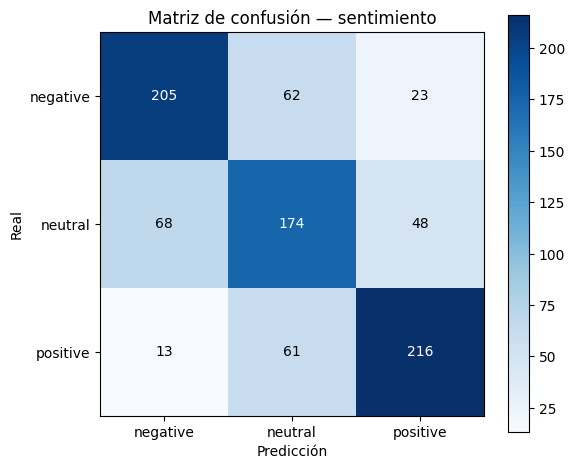

In [34]:
# TODO: classification_report + confusion_matrix sobre el test. ¿Que clase se confunde mas?
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

salida = trainer.predict(ds_te)
preds = np.argmax(salida.predictions, axis=-1)
labels_reales = salida.label_ids

print(classification_report(labels_reales, preds, target_names=clases))

cm = confusion_matrix(labels_reales, preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(clases))); ax.set_xticklabels(clases)
ax.set_yticks(range(len(clases))); ax.set_yticklabels(clases)
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusión — sentimiento')

for i in range(len(clases)):
    for j in range(len(clases)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.show()

_¿Qué clase es la más difícil? ¿Accuracy o F1-macro es mejor criterio aquí? ¿Por qué?_

La clase más dificil es la neutral, tiene los valores más bajos, tanto en recall como en F1

Aquí es mejor F1-Macro

**B.5 · Uso del modelo afinado** — transferencia al corpus chiapaneco. El modelo se entrenó con tuits; veamos qué predice sobre noticias.

In [35]:
from transformers import pipeline
# TODO: crear un pipeline('text-classification') con su modelo afinado y aplicarlo a
#       3-4 frases propias + algunas del corpus (crudo[...]). Comenten el domain shift.

clasificador = pipeline(
    'text-classification',
    model=model,
    tokenizer=tok,
    device=0 if torch.cuda.is_available() else -1,
)

frases_propias = [
    "Qué horrible servicio, nunca más vuelvo a este lugar",
    "El clima hoy está agradable, nada especial",
    "Me encantó la película, la mejor que he visto este año",
]

print("── Frases propias (estilo tuit) ──")
for frase in frases_propias:
    pred = clasificador(frase)[0]
    print(f"  [{pred['label']:>9} {pred['score']:.3f}]  {frase}")

ids_muestra = ids[:4]   #

print("\n── Fragmentos del corpus (noticias) ──")
for id_ in ids_muestra:
    texto = crudo[id_][:200]
    pred = clasificador(texto)[0]
    print(f"  [{pred['label']:>9} {pred['score']:.3f}]  {id_}: {texto[:80]}...")


── Frases propias (estilo tuit) ──
  [ negative 0.936]  Qué horrible servicio, nunca más vuelvo a este lugar
  [ positive 0.883]  El clima hoy está agradable, nada especial
  [ positive 0.949]  Me encantó la película, la mejor que he visto este año

── Fragmentos del corpus (noticias) ──
  [  neutral 0.602]  d01: Las  fuertes lluvias   provocaron inundaciones en varias colonias del sur de Tux...
  [ negative 0.875]  d02: La crisis hidrica se agrava: el desabasto del liquido vital afecta a miles de fa...
  [ negative 0.829]  d03: <p>El <b>cafe</b> de Chiapas rompio su record historico de exportacion este cicl...
  [ negative 0.831]  d04: La sequia afecta gravemente los cultivos de maiz y frijol en la region fronteriz...


**Liberar memoria** antes de la Parte C.

> Añadir blockquote



In [36]:
del model            # y el trainer/pipeline si los nombraron distinto
liberar_memoria()

VRAM en uso: 1.79 GB


---
## Parte C · NER con CoNLL-2002 (español)

Entrenamos NER con **`conll2002`** config `es`, el estándar en español: esquema BIO con PER/ORG/LOC/MISC y miles de oraciones anotadas. *Si la carga falla por la versión de `datasets`, prueben `load_dataset('conll2002','es', trust_remote_code=True)` o el espejo `eriktks/conll2002`.*


**C.1** Cargar el dataset y leer el esquema de etiquetas desde sus features.

In [38]:
from datasets import Dataset, DatasetDict, Features, Sequence, Value, ClassLabel
import requests

pos_names = [
    "AO", "AQ", "CC", "CS", "DA", "DE", "DD", "DI", "DN", "DP",
    "DT", "Faa", "Fat", "Fc", "Fd", "Fe", "Fg", "Fh", "Fia", "Fit",
    "Fp", "Fpa", "Fpt", "Fs", "Ft", "Fx", "Fz", "I", "NC", "NP",
    "P0", "PD", "PI", "PN", "PP", "PR", "PT", "PX", "RG", "RN",
    "SP", "VAI", "VAM", "VAN", "VAP", "VAS", "VMG", "VMI", "VMM",
    "VMN", "VMP", "VMS", "VSG", "VSI", "VSM", "VSN", "VSP", "VSS",
    "Y", "Z"
]

ner_names = [
    "O", "B-PER", "I-PER", "B-ORG", "I-ORG",
    "B-LOC", "I-LOC", "B-MISC", "I-MISC"
]

pos2id = {nombre: i for i, nombre in enumerate(pos_names)}
ner2id = {nombre: i for i, nombre in enumerate(ner_names)}

features_conll = Features({
    "id": Value("string"),
    "tokens": Sequence(Value("string")),
    "pos_tags": Sequence(ClassLabel(names=pos_names)),
    "ner_tags": Sequence(ClassLabel(names=ner_names)),
})

def leer_conll2002(url):
    texto = requests.get(url, timeout=30).text

    ejemplos = []
    tokens = []
    pos_tags = []
    ner_tags = []
    guid = 0

    for linea in texto.splitlines():
        linea = linea.strip()

        if linea.startswith("-DOCSTART-") or linea == "":
            if tokens:
                ejemplos.append({
                    "id": str(guid),
                    "tokens": tokens,
                    "pos_tags": pos_tags,
                    "ner_tags": ner_tags,
                })
                guid += 1
                tokens = []
                pos_tags = []
                ner_tags = []
        else:
            partes = linea.split()
            token, pos, ner = partes[0], partes[1], partes[2]

            tokens.append(token)
            pos_tags.append(pos2id[pos])
            ner_tags.append(ner2id[ner])

    if tokens:
        ejemplos.append({
            "id": str(guid),
            "tokens": tokens,
            "pos_tags": pos_tags,
            "ner_tags": ner_tags,
        })

    return Dataset.from_list(ejemplos, features=features_conll)

def cargar_conll2002_es():
    base = "https://raw.githubusercontent.com/teropa/nlp/master/resources/corpora/conll2002"

    return DatasetDict({
        "train": leer_conll2002(f"{base}/esp.train"),
        "validation": leer_conll2002(f"{base}/esp.testa"),
        "test": leer_conll2002(f"{base}/esp.testb"),
    })

In [40]:
from datasets import load_dataset
conll = cargar_conll2002_es()
# TODO: obtener 'etiquetas' (features['ner_tags'].feature.names) y los mapeos id2lab/lab2id.
etiquetas = conll['train'].features['ner_tags'].feature.names
print(etiquetas)
# algo como ['O', 'B-PER', 'I-PER', 'B-PER', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

id2lab = {i: nombre for i, nombre in enumerate(etiquetas)}
lab2id = {nombre: i for i, nombre in enumerate(etiquetas)}

print(id2lab)
print(lab2id)

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
{0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC', 7: 'B-MISC', 8: 'I-MISC'}
{'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6, 'B-MISC': 7, 'I-MISC': 8}


**C.2 — el corazón del lab.** Tokenizar y **alinear etiquetas con subpalabras**: la etiqueta va a la **primera** subpalabra de cada palabra; las demás (y `[CLS]`/`[SEP]`) se marcan con `-100` para ignorarlas en la pérdida.

In [41]:
from transformers import AutoTokenizer
CKPT = 'dccuchile/bert-base-spanish-wwm-cased'
tok = AutoTokenizer.from_pretrained(CKPT)
def tokeniza_y_alinea(batch):
    # TODO: tok(..., is_split_into_words=True); por cada ejemplo usar enc.word_ids(batch_index=i)
    #       para poner la etiqueta SOLO en la primera subpalabra y -100 en las demas y en [CLS]/[SEP].
    enc = tok(
        batch['tokens'],
        truncation=True,
        is_split_into_words=True,
        padding='max_length',
        max_length=128,
    )

    labels_alineadas = []
    for i, etiquetas_palabra in enumerate(batch['ner_tags']):
        word_ids = enc.word_ids(batch_index=i)
        etiquetas_finales = []
        palabra_anterior = None

        for wid in word_ids:
            if wid is None:
                # [CLS], [SEP], padding
                etiquetas_finales.append(-100)
            elif wid != palabra_anterior:
                # primera subpalabra de una palabra nueva
                etiquetas_finales.append(etiquetas_palabra[wid])
            else:
                # subpalabra de continuación (misma palabra que la anterior)
                etiquetas_finales.append(-100)
            palabra_anterior = wid

        labels_alineadas.append(etiquetas_finales)

    enc['labels'] = labels_alineadas
    return enc

# conll_tok = conll.map(tokeniza_y_alinea, batched=True, remove_columns=conll['train'].column_names)
conll_tok = conll.map(
    tokeniza_y_alinea,
    batched=True,
    remove_columns=conll['train'].column_names,
)

ejemplo = conll_tok['train'][0]
tokens_decoded = tok.convert_ids_to_tokens(ejemplo['input_ids'])

for t, l in zip(tokens_decoded[:20], ejemplo['labels'][:20]):
    etiqueta = id2lab[l] if l != -100 else '—'
    print(f"{t:15} {etiqueta}")

Map:   0%|          | 0/8323 [00:00<?, ? examples/s]

Map:   0%|          | 0/1915 [00:00<?, ? examples/s]

Map:   0%|          | 0/1517 [00:00<?, ? examples/s]

[CLS]           —
Mel             B-LOC
##bourne        —
(               O
Australia       B-LOC
)               O
,               O
25              O
may             O
(               O
EF              B-ORG
##E             —
)               O
.               O
[SEP]           —
[PAD]           —
[PAD]           —
[PAD]           —
[PAD]           —
[PAD]           —


**C.3** Fine-tuning con `AutoModelForTokenClassification` (`fp16`, T4).

In [48]:
from transformers import (AutoModelForTokenClassification, TrainingArguments, Trainer,
                          DataCollatorForTokenClassification)
# TODO: AutoModelForTokenClassification (num_labels, id2label, label2id);
#       DataCollatorForTokenClassification; TrainingArguments (fp16 en T4); Trainer; entrenar.
model = AutoModelForTokenClassification.from_pretrained(
    CKPT,
    num_labels=len(etiquetas),
    id2label=id2lab,
    label2id=lab2id,
)

collator = DataCollatorForTokenClassification(tokenizer=tok)

args = TrainingArguments(
    output_dir='./resultados_ner',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    fp16=True,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    report_to='none',
)

trainer_ner = Trainer(
    model=model,
    args=args,
    train_dataset=conll_tok['train'],
    eval_dataset=conll_tok['validation'],
    data_collator=collator,
)

trainer_ner.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.053002,0.081012
2,0.037805,0.078935
3,0.022107,0.084152


TrainOutput(global_step=1563, training_loss=0.06515867471389868, metrics={'train_runtime': 193.9734, 'train_samples_per_second': 128.724, 'train_steps_per_second': 8.058, 'total_flos': 1631182905176832.0, 'train_loss': 0.06515867471389868, 'epoch': 3.0})

**C.4** Evaluación con **seqeval** (a nivel de entidad, no de token).

In [43]:
from seqeval.metrics import classification_report as seq_report
# TODO: predecir; reconstruir secuencias ignorando -100; evaluar con seqeval (entidad).
#       Expliquen por que NO se usa accuracy por token.
salida = trainer_ner.predict(conll_tok['validation'])
preds_ids = np.argmax(salida.predictions, axis=-1)
labels_ids = salida.label_ids

preds_finales = []
labels_finales = []

for pred_seq, label_seq in zip(preds_ids, labels_ids):
    pred_oracion = []
    label_oracion = []
    for p, l in zip(pred_seq, label_seq):
        if l == -100:
            continue
        pred_oracion.append(id2lab[p])
        label_oracion.append(id2lab[l])
    preds_finales.append(pred_oracion)
    labels_finales.append(label_oracion)

print(seq_report(labels_finales, preds_finales))


              precision    recall  f1-score   support

         LOC       0.84      0.87      0.86       972
        MISC       0.64      0.58      0.61       445
         ORG       0.84      0.88      0.86      1658
         PER       0.94      0.94      0.94      1216

   micro avg       0.85      0.86      0.86      4291
   macro avg       0.82      0.82      0.82      4291
weighted avg       0.85      0.86      0.86      4291



_¿Por qué seqeval y no accuracy por token? ¿Qué tipo de entidad cuesta más?_\

Accuracy se infla con la clase mayoritaria O y porque puede llegar a contar como "casi correcto" una entidad mal delimitada

La entidad más difícil es MISC, con el F1 más bajo (0.61) frente a PER (0.94), ORG (0.86) y LOC (0.86).

**C.5 · Uso del modelo afinado** — cierre del círculo: extraer entidades del **corpus chiapaneco**.

In [49]:
from transformers import pipeline
# TODO: pipeline('ner', aggregation_strategy='simple') con su modelo; aplicarlo a 3 documentos
#       del corpus (crudo[...]) e imprimir las entidades detectadas con su tipo y score.
ner_pipe = pipeline(
    'ner',
    model=model,
    tokenizer=tok,
    aggregation_strategy='simple',
    device=0 if torch.cuda.is_available() else -1,
)

ids_muestra = ids[:3]

for id_ in ids_muestra:
    texto = crudo[id_]
    entidades = ner_pipe(texto)

    print(f"── {id_}: {titulos[id_]} ──")
    if not entidades:
        print("  (sin entidades detectadas)")
    for ent in entidades:
        print(f"  {ent['entity_group']:5}  {ent['score']:.3f}  {ent['word']}")
    print()

── d01: Lluvias provocan inundaciones en Tuxtla ──
  LOC    0.994  Tu
  LOC    0.893  ##xtla
  PER    0.941  Gutierrez 😟
  ORG    0.946  Prote
  ORG    0.751  ##ccion Civil
  MISC   0.511  h
  MISC   0.538  ##ttps : /
  MISC   0.477  ##apas
  ORG    0.481  ##parale

── d02: Crisis hidrica golpea la region ──
  (sin entidades detectadas)

── d03: Cafe de Chiapas rompe record de exportacion ──
  LOC    0.988  Chiapas
  LOC    0.995  Europa
  LOC    0.994  Asia
  LOC    0.982  Sierra



**Liberar memoria** al terminar.

In [50]:
del model
liberar_memoria()

VRAM en uso: 3.11 GB


---
## Síntesis

Las tres partes usaron **el mismo BERT preentrenado** y solo cambiaron la cabeza y los datos: cabeza siamesa con sus qrels (A), `[CLS]` + lineal con un dataset de sentimiento real (B), y una etiqueta por token con CoNLL-2002 (C). Cada modelo afinado se aplicó **sobre su propio corpus**, y entre entrenamientos se liberó memoria para sostener la sesión en una T4. Ese paradigma —preentrenar una vez, adaptar barato— es la base de los sistemas RAG de la Unidad 3.


## Entregables — Lab 6
- [ ] **A:** fine-tuning de Sentence-BERT + los tres nDCG + búsqueda con el modelo afinado.
- [ ] **B:** clasificación con dataset real + matriz de confusión + inferencia sobre el corpus.
- [ ] **C:** NER con CoNLL-2002 + alineación de subpalabras + seqeval + extracción sobre el corpus.
- [ ] Celdas de liberación de memoria ejecutadas entre partes.
- [ ] `AI_USAGE.md` actualizado si usaron IA.
